# Fans most favorites genre analysis

In [1]:
import duckdb
import pandas as pd
import sys
import os

sys.path.append(os.path.abspath('lib'))

from lib.dbconnection import load_config, db_config, create_db_engine
load_config()

Analisi completata con successo:
                Avg Completed  Avg Score
activity_level                          
Novizio             35.450955   3.865109
Appassionato       162.716022   4.123288
Veterano           462.555546   4.112114


In [ ]:
con = duckdb.connect()

In [ ]:
ratings_path = '../../../cleaned_data/ratings_cleaned.parquet'

query = f"""
    WITH user_scores AS (
        SELECT
            username,
            AVG(cast(score as int)) as mean_score
        FROM '{ratings_path}'
        GROUP BY username
    )
    SELECT
        p.username,
        p.completed,
        COALESCE(s.mean_score, 0) as mean_score
    FROM anime_db.profiles p
    LEFT JOIN user_scores s ON p.username = s.username
    WHERE p.completed IS NOT NULL
"""


In [ ]:
profiles = con.sql(query).df()

profiles['completed'] = pd.to_numeric(profiles['completed'], errors='coerce')
profiles = profiles.dropna(subset=['completed'])

profiles['activity_level'] = pd.qcut(
    profiles['completed'],
    q=3,
    labels=['Novizio', 'Appassionato', 'Veterano']
)

print("Analisi completata con successo:")
summary = profiles.groupby('activity_level', observed=True)[['completed', 'mean_score']].mean()
summary.columns = ['Avg Completed', 'Avg Score']
print(summary)

In [2]:
engine = create_db_engine()
df_details = pd.read_sql("SELECT mal_id, genres, start_date FROM public.details", engine)

print("DataFrame df_details caricato e pulito con successo.")

con.register('df_details_clean', df_details)

query_genres = f"""
    WITH exploded_genres AS (
        SELECT
            unnest(string_split(d.genres, ',')) as genre,
            r.score
        FROM read_parquet('{ratings_path}') r
        JOIN df_details_clean d ON r.anime_id = d.mal_id
    )
    SELECT
        trim(genre) as Genre,
        COUNT(*) as Total_Views,
        ROUND(AVG(CAST(score AS DOUBLE)), 2) as Average_Score
    FROM exploded_genres
    WHERE genre IS NOT NULL AND genre != '' AND genre != 'None'
    GROUP BY Genre
    ORDER BY Total_Views DESC
    LIMIT 10
"""

df_popular_genres = con.sql(query_genres).df()

print("### TOP 10 MOST POPULAR GENRES ###")
print(df_popular_genres)

DataFrame df_details caricato e pulito con successo.
### TOP 10 MOST POPULAR GENRES ###
          Genre  Total_Views  Average_Score
0        Action     52823490           4.26
1       Fantasy     34741598           4.19
2       Romance     26558813           4.05
3        Comedy     25339034           3.90
4        Sci-Fi     17395907           3.86
5     Adventure     17066587           4.30
6  Supernatural     16610334           4.23
7        Comedy     15694458           4.25
8         Drama     15441847           4.39
9         Drama     13040842           4.12


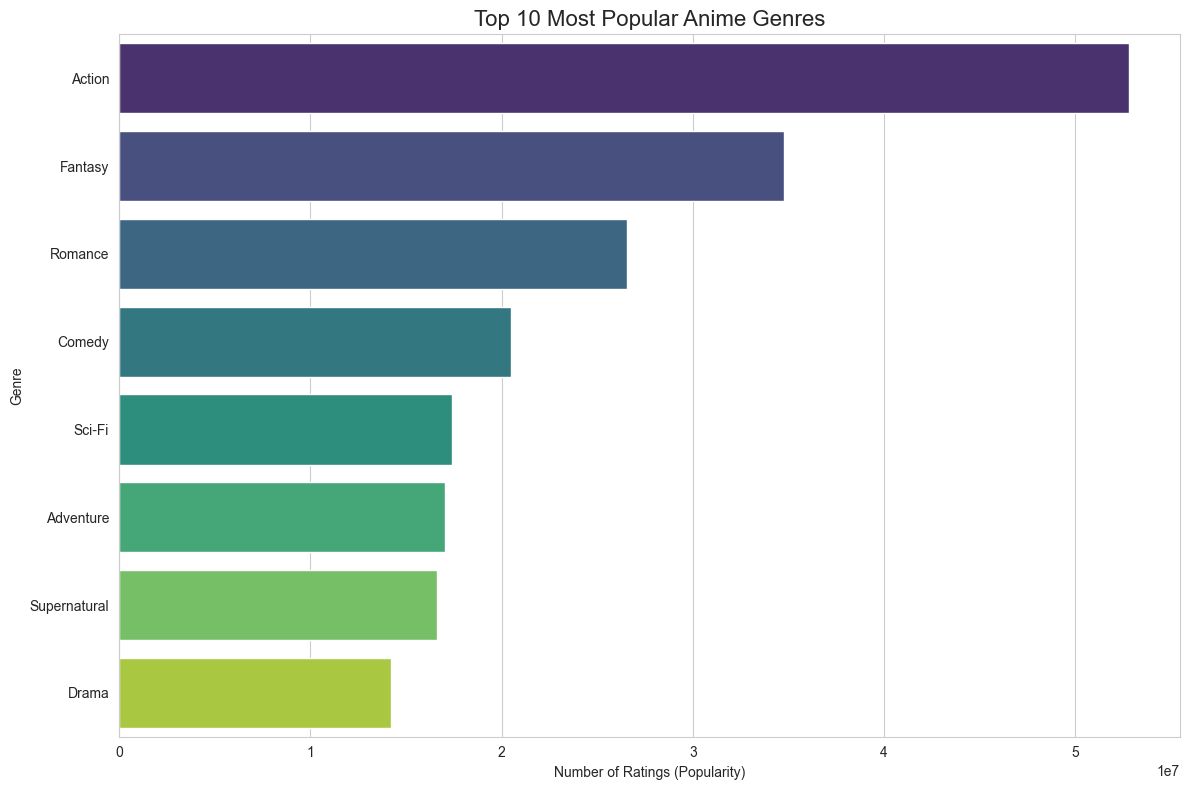

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

sns.barplot(
    data=df_popular_genres,
    x='Total_Views',
    y='Genre',
    hue='Genre',
    palette='viridis',
    legend=False,
    errorbar=None
)

plt.title('Top 10 Most Popular Anime Genres', fontsize=16)
plt.xlabel('Number of Ratings (Popularity)')
plt.ylabel('Genre')

plt.savefig('../../graphs/topGenres.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

In [4]:
query_evolution = f"""
    WITH cleaned_data AS (
        SELECT
            EXTRACT(YEAR FROM TRY_CAST(d.start_date AS DATE)) as release_year,
            trim(unnest(string_split(d.genres, ','))) as genre,
            CAST(r.score AS DOUBLE) as score
        FROM df_details_clean d
        JOIN read_parquet('{ratings_path}') r ON r.anime_id = d.mal_id
        WHERE d.start_date IS NOT NULL
          AND d.start_date != 'Unknown'
    ),
    genre_yearly_stats AS (
        SELECT
            release_year,
            genre,
            AVG(score) as avg_score,
            COUNT(*) as vote_count
        FROM cleaned_data
        WHERE release_year BETWEEN 1990 AND 2024
        GROUP BY release_year, genre
    ),
    ranked_genres AS (
        SELECT
            *,
            ROW_NUMBER() OVER(PARTITION BY release_year ORDER BY avg_score DESC) as rnk
        FROM genre_yearly_stats
        WHERE vote_count > 50
    )
    SELECT release_year, genre, ROUND(avg_score, 2) as avg_score
    FROM ranked_genres
    WHERE rnk = 1
    ORDER BY release_year
"""

df_evolution = con.sql(query_evolution).df()


In [5]:
# Selezioniamo i 10 generi più frequenti come "vincitori" per non avere una heatmap infinita
top_genres = df_evolution['genre'].value_counts().nlargest(10).index

pivot_evolution = df_evolution[df_evolution['genre'].isin(top_genres)].pivot(
    index='genre',
    columns='release_year',
    values='avg_score'
)

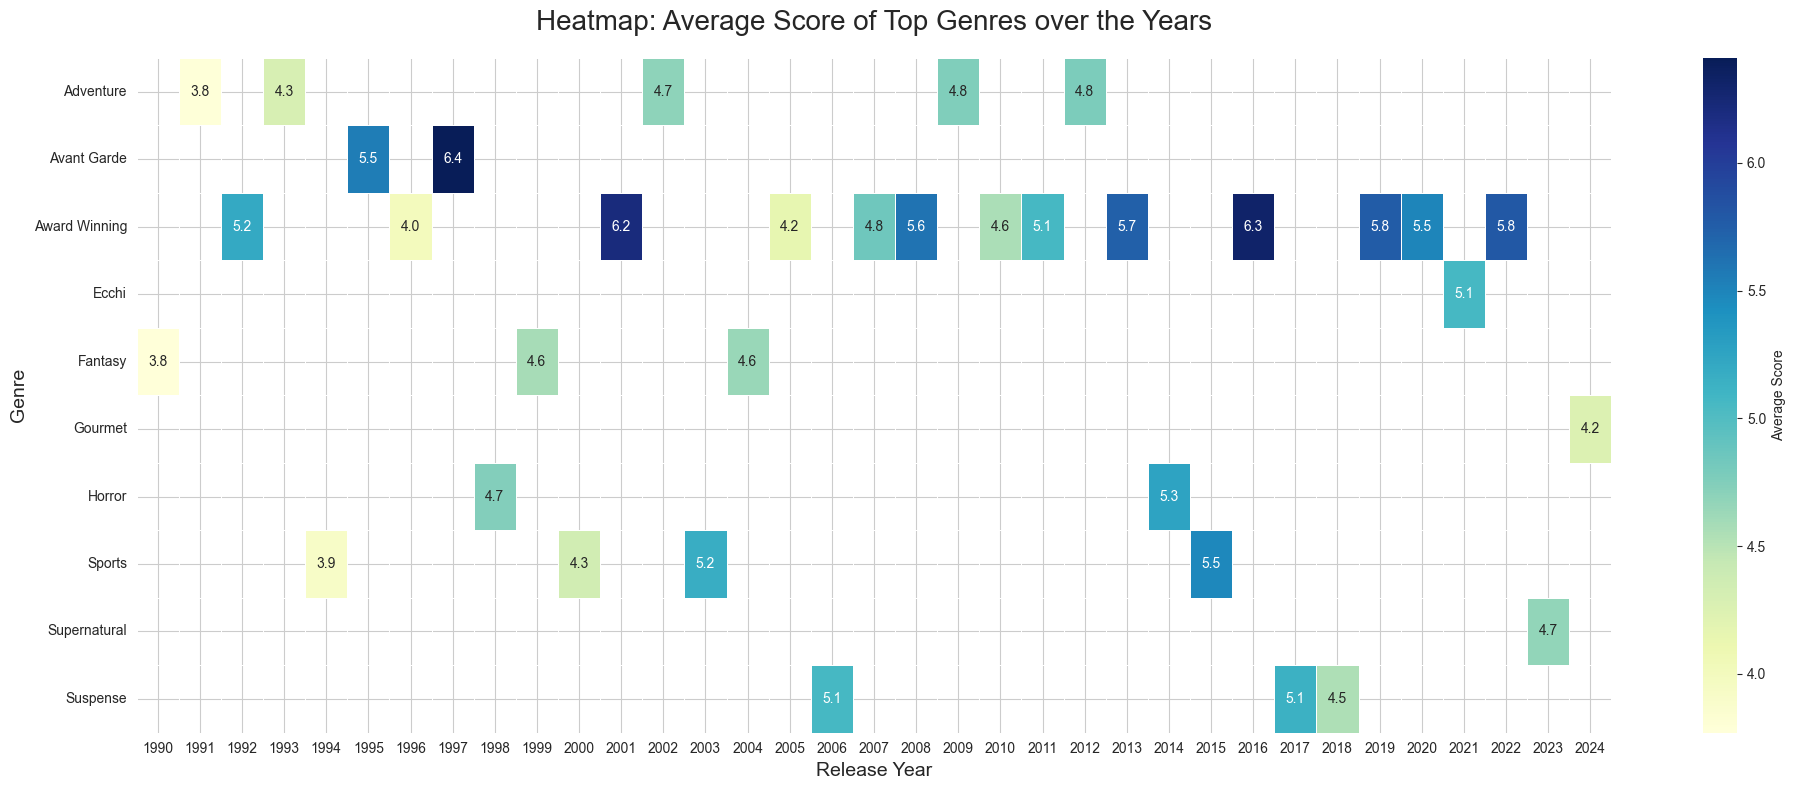

In [6]:
plt.figure(figsize=(20, 8))

sns.heatmap(
    pivot_evolution,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar_kws={'label': 'Average Score'},
    linewidths=.5
)

plt.title('Heatmap: Average Score of Top Genres over the Years', fontsize=20, pad=20)
plt.xlabel('Release Year', fontsize=14)
plt.ylabel('Genre', fontsize=14)

plt.savefig('../../graphs/avgScoreTime.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()